# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


probeA has 12.225 neurons in cross-pop in average. 
probeB has 14.95 neurons in cross-pop in average. 
probeC has 16.9 neurons in cross-pop in average. 
probeD has 10.625 neurons in cross-pop in average. 
probeE has 7.375 neurons in cross-pop in average. 
probeF has 8.225 neurons in cross-pop in average. 

# Baseline (no coupling)

In [7]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    # for j, input_probe in enumerate(probe_list):
    #     model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    # for j, input_probe in enumerate(probe_list):
    #     model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
    # model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
baseline_aic = aic
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
baseline_bic = bic
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [02:56, 29.48s/it]

AIC improvement of the model is: 0.0
BIC improvement of the model is: 0.0


In [64]:
baseline_aic

593354.6231978959

In [8]:
baseline_bic

606684.2438227601

/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

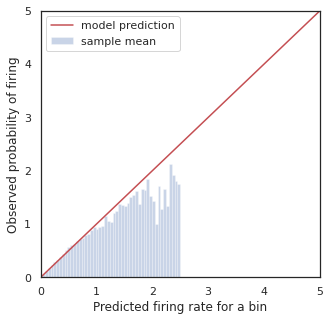

In [11]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

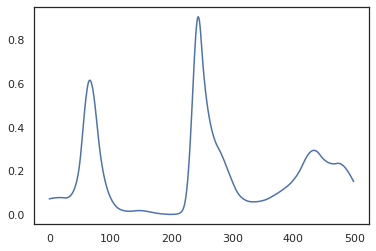

In [12]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# Only cross-area coupling

In [13]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if j == i:
            continue
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if j == i:
            continue
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    # model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [03:03, 30.59s/it]

AIC improvement of the model is: 19146.308603037847
BIC improvement of the model is: 17554.795605008607


/tmp/ipykernel_129107/49931424.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

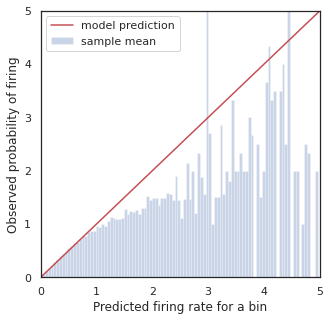

In [14]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])


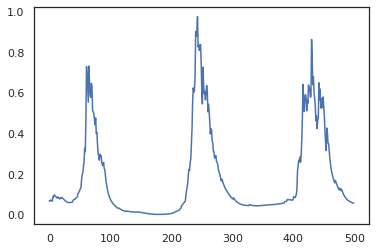

In [15]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# Both cross-area coupling and history

This is unstable when doing simulation

In [16]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    # model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [03:20, 33.46s/it]

AIC improvement of the model is: 22493.101824379875
BIC improvement of the model is: 20583.286226744996


/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

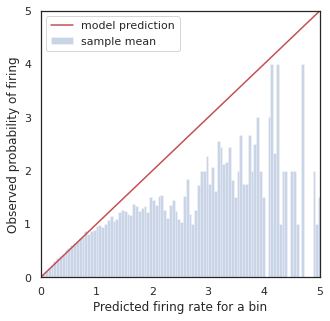

In [17]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

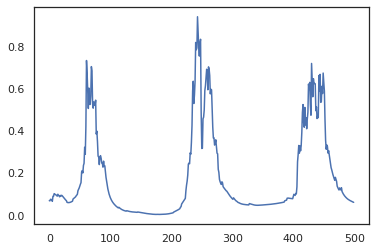

In [18]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# Underfit cases, whose predicted firing rate is greater than 1, are mostly those cases with spike density >0.75. So using spike density to correct bias might be useful. 

In [460]:
record_spike_density = []
for model in model_list:
    record_spike_density.append(model.effect_list[7].flatten('F'))
record_spike_density = np.hstack(record_spike_density)

record_lmbd = []
for model in model_list:
    record_lmbd.append(np.exp(model.log_lmbd).flatten('F'))
record_lmbd = np.hstack(record_lmbd)

(array([   0., 1000., 2000., 3000., 4000., 5000.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

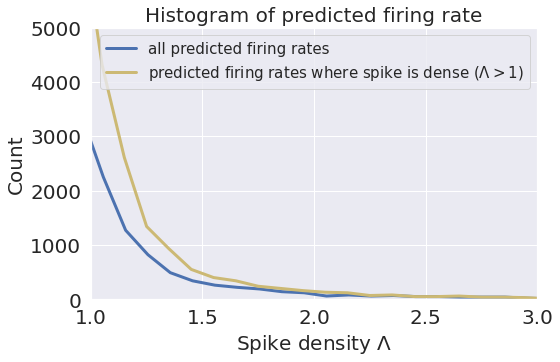

In [478]:
Lambda_threshold = 1

fontsize = 20
sns.set_theme()
plt.subplots(figsize=(8,5))
sns.histplot(record_lmbd[record_spike_density>Lambda_threshold], 
             stat='frequency', color='b', binwidth=0.1, element="poly", 
             label='all predicted firing rates', fill=False, linewidth=3)
sns.histplot(record_lmbd, 
             stat='frequency', color='y', binwidth=0.1, element="poly", 
             label='predicted firing rates where spike is dense ($\Lambda > 1$)', fill=False, linewidth=3)
plt.xlim([1, 3])
plt.ylim([0, 5e3])
plt.legend(prop={'size': 15})
plt.xlabel('Spike density $\Lambda$', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.title('Histogram of predicted firing rate', fontsize=fontsize)
plt.xticks([1, 1.5, 2, 2.5, 3], fontsize=fontsize)
plt.yticks(fontsize=fontsize)

(array([     0.,  20000.,  40000.,  60000.,  80000., 100000.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

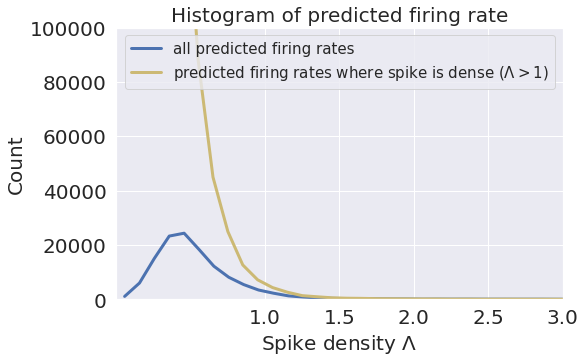

In [479]:
Lambda_threshold = 1

fontsize = 20
sns.set_theme()
plt.subplots(figsize=(8,5))
sns.histplot(record_lmbd[record_spike_density>Lambda_threshold], 
             stat='frequency', color='b', binwidth=0.1, element="poly", 
             label='all predicted firing rates', fill=False, linewidth=3)
sns.histplot(record_lmbd, 
             stat='frequency', color='y', binwidth=0.1, element="poly", 
             label='predicted firing rates where spike is dense ($\Lambda > 1$)', fill=False, linewidth=3)
plt.xlim([0.0, 3])
plt.ylim([0, 1e5])
plt.legend(prop={'size': 15})
plt.xlabel('Spike density $\Lambda$', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.title('Histogram of predicted firing rate', fontsize=fontsize)
plt.xticks([1, 1.5, 2, 2.5, 3], fontsize=fontsize)
plt.yticks(fontsize=fontsize)

It seems like those uncalibrated cases (firing rate>1) are pretty much all those cases with unusual spike density

# With interaction in history effect

In [19]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [03:18, 33.06s/it]

AIC improvement of the model is: 26969.998001426808
BIC improvement of the model is: 24741.879804186057


/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

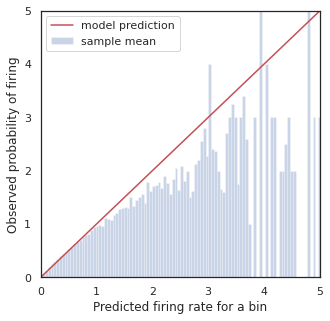

In [20]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

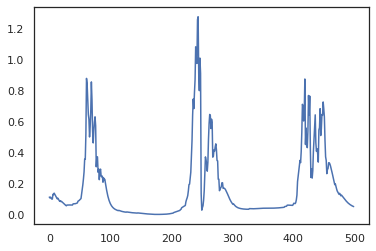

In [21]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# With only 2nd interaction in history effect

In [22]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
#     model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, 
#                                 apply_no_penalty=True)
    model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, 
                                apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
#     model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, 
#                              apply_no_penalty=True)
    model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [03:13, 32.30s/it]

AIC improvement of the model is: 25465.847453598515
BIC improvement of the model is: 23237.729256357765


/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

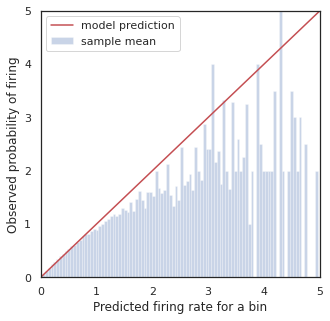

In [23]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

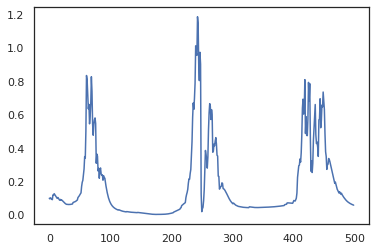

In [24]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# With both 1st and 2nd interaction in history effect

In [25]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, 
                                apply_no_penalty=True)
    model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, 
                                apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [03:11, 31.88s/it]

AIC improvement of the model is: 28774.93183615338
BIC improvement of the model is: 26228.511039306875


/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

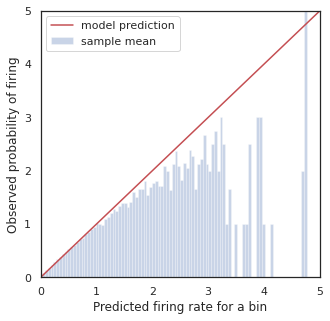

In [26]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

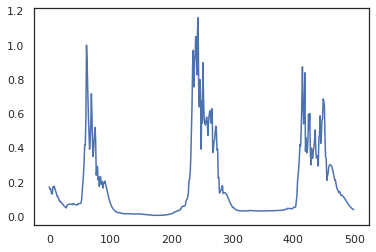

In [27]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# With $\Lambda$ in history effect

In [28]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [03:02, 30.35s/it]

AIC improvement of the model is: 23293.578463368933
BIC improvement of the model is: 21277.661999198725


/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

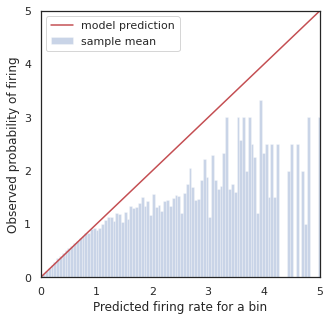

In [29]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

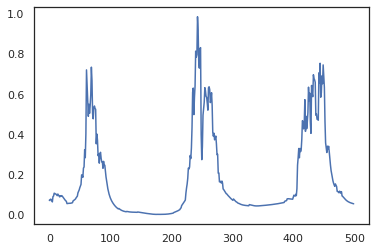

In [30]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# With $\Lambda^2$ refractory in history effect

In [31]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [03:03, 30.59s/it]

AIC improvement of the model is: 26717.91897189268
BIC improvement of the model is: 24702.002507722587


/tmp/ipykernel_129107/2939886968.py:20: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


Text(0.5, 1.0, 'previous quadratic term model')

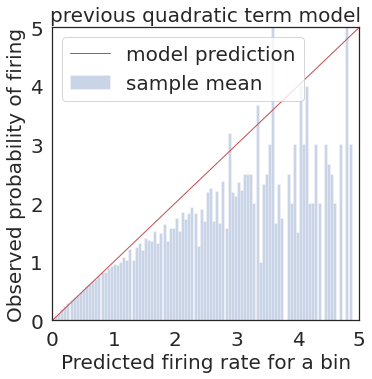

In [32]:
fontsize = 20
# plt.subplots(figsize=(8,5.3))

model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)

plt.subplots(figsize=(5*1.1,4.9*1.1))
plt.plot(xx, xx, label='model prediction',color='r',linewidth=1)
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)

plt.xlim([0, 5])
plt.ylim([0, 5])

plt.legend(prop={'size': fontsize})
plt.xlabel('Predicted firing rate for a bin', fontsize=fontsize)
plt.ylabel('Observed probability of firing', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title('previous quadratic term model', fontdict = {'fontsize' : 20})

Text(0.5, 1.0, 'LM; Resting; trial 85')

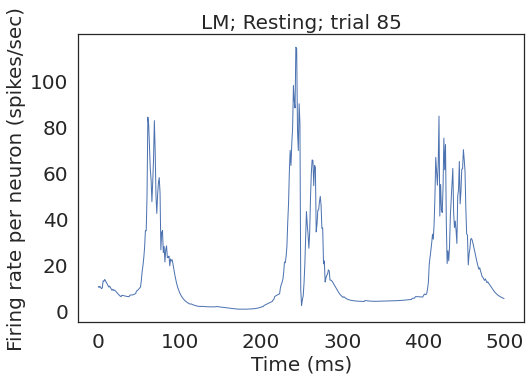

In [33]:
fontsize = 20
plt.subplots(figsize=(8,5.3))

plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85])/10.625*1e3, linewidth=1)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel("Time (ms)", fontsize=fontsize)
plt.ylabel("Firing rate per neuron (spikes/sec)", fontsize=fontsize)
plt.title("LM; Resting; trial 85", fontdict = {'fontsize' : 20})

In [30]:
num_sum[:20].sum()/num_sum.sum()

0.9851488056026909

# With $\Lambda^{1.5}$ refractory in history effect

In [34]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")


6it [03:07, 31.27s/it]

AIC improvement of the model is: 27907.19182579359
BIC improvement of the model is: 25891.2753616235


10: 29476.736379548907
13: 29464.559565856704
15： 29502.134585163323

/tmp/ipykernel_129107/4052665448.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


Text(0.5, 1.0, 'previous quadratic term model')

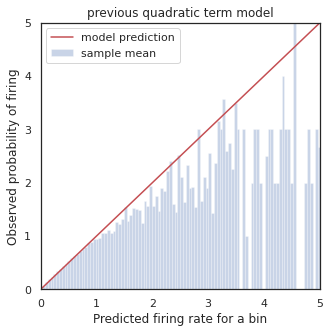

In [35]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.title('previous quadratic term model')

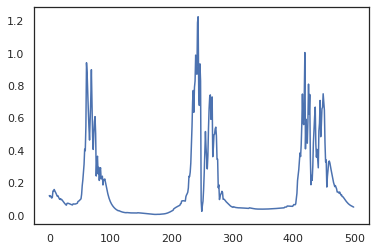

In [36]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# Refractory box

Doesn't work

# refractory nonparametric

In [37]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}


for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    filter_list = model_stationary.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
    filter_list = model_running.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")


6it [03:21, 33.60s/it]

AIC improvement of the model is: 29497.677176633268
BIC improvement of the model is: 27163.458112857305


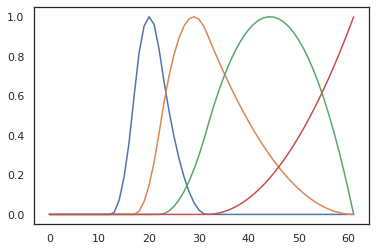

In [38]:
plt.plot(model_running.basis_list[7])

5: 29732.166410775273
10:31210.40242647822
15:31368.73692790442

/tmp/ipykernel_129107/3699017344.py:20: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


Text(0.5, 1.0, '$f_{rf}(\\Lambda)$ model')

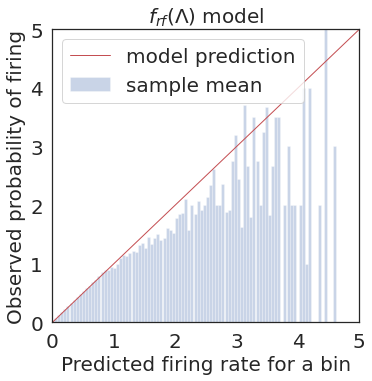

In [39]:
fontsize = 20
# plt.subplots(figsize=(8,5.3))

model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)

plt.subplots(figsize=(5*1.1,4.9*1.1))
plt.plot(xx, xx, label='model prediction',color='r',linewidth=1)
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)

plt.xlim([0, 5])
plt.ylim([0, 5])

plt.legend(prop={'size': fontsize})
plt.xlabel('Predicted firing rate for a bin', fontsize=fontsize)
plt.ylabel('Observed probability of firing', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title('$f_{rf}(\Lambda)$ model', fontdict = {'fontsize' : 20})

Text(0.5, 1.0, 'Fitted with $f_{rf}(\\Lambda)$ model; LM; Resting; trial 85')

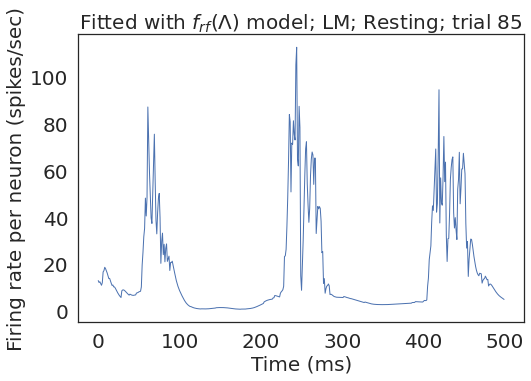

In [40]:
fontsize = 20
plt.subplots(figsize=(8,5.3))

plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85])/10.625*1e3, linewidth=1)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel("Time (ms)", fontsize=fontsize)
plt.ylabel("Firing rate per neuron (spikes/sec)", fontsize=fontsize)
plt.title("Fitted with $f_{rf}(\Lambda)$ model; LM; Resting; trial 85", fontdict = {'fontsize' : 20})

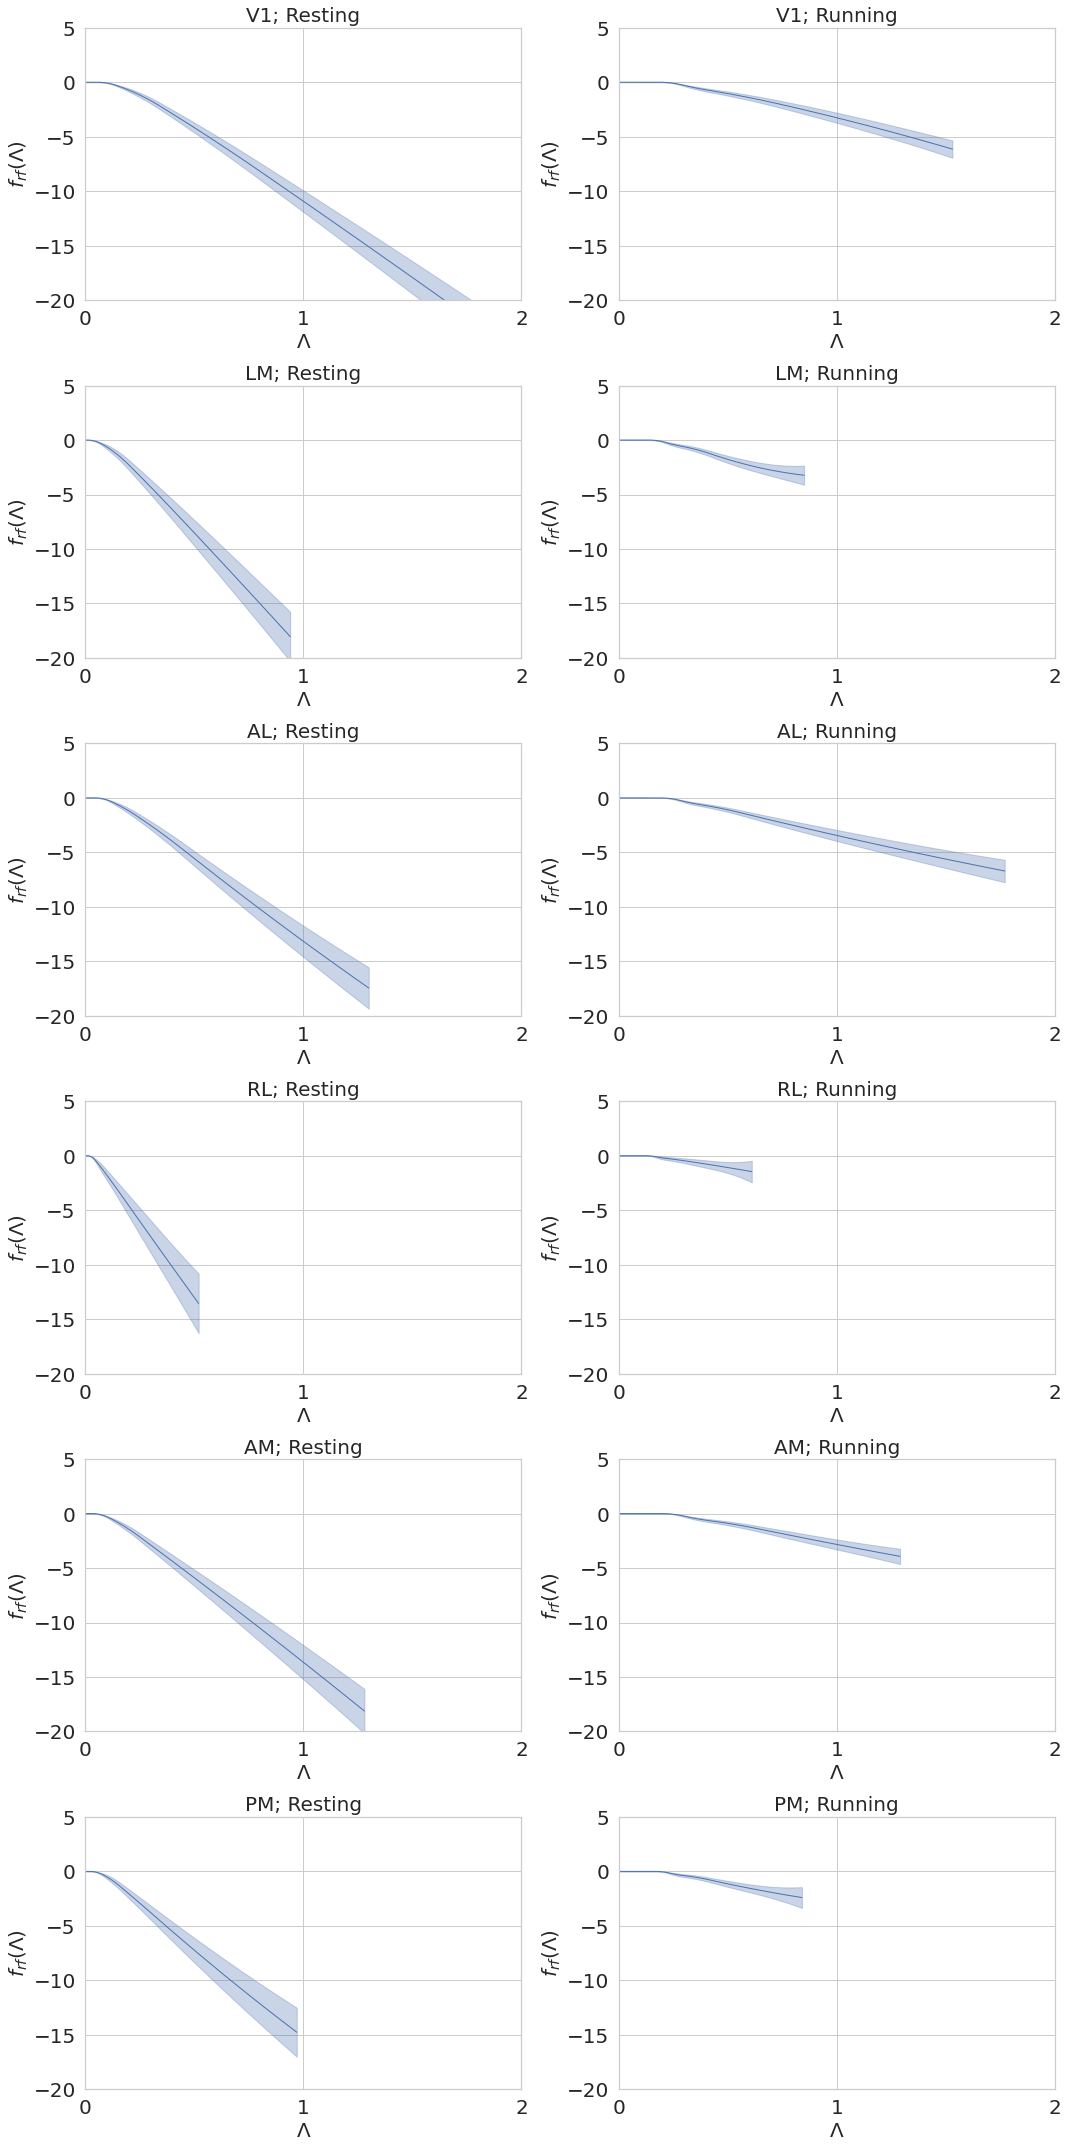

In [41]:
sns.set_style('whitegrid')
# sns.reset_orig()
fontsize = 20
plt.subplots(figsize=(15,30))
transfer_ij = {4:0, 5:1, 0:2, 1:3, 2:4, 3:5}

for ii in range(6):
    i = transfer_ij[ii]
    for j in range(7,8):
        plt.subplot(6,2, 2*ii+j-6)
        model = model_list[i]
        utils.plot_ci(model.get_filter(ci=True)[j], center=True)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.xlabel('$\Lambda$', fontsize=fontsize)
        plt.ylabel('$f_{rf}(\Lambda)$', fontsize=fontsize)
        plt.ylim([-20, 5])
        plt.xlim([0, 200])
        plt.xticks([0, 100, 200], [0, 1, 2])
        plt.title(utils.PROBE_CORRESPONDING[probe_list[i]]+"; Resting", fontdict = {'fontsize' : 20})
    for j in range(7,8):
        plt.subplot(6,2, 2*ii+j-5)
        model = model_list[i+6]
        utils.plot_ci(model.get_filter(ci=True)[j], center=True)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.xlabel('$\Lambda$', fontsize=fontsize)
        plt.ylabel('$f_{rf}(\Lambda)$', fontsize=fontsize)
        plt.ylim([-20, 5])
        plt.xlim([0, 200])
        plt.xticks([0, 100, 200], [0, 1, 2])
        plt.title(utils.PROBE_CORRESPONDING[probe_list[i]]+"; Running", fontdict = {'fontsize' : 20})
plt.tight_layout()
sns.set_style('white')

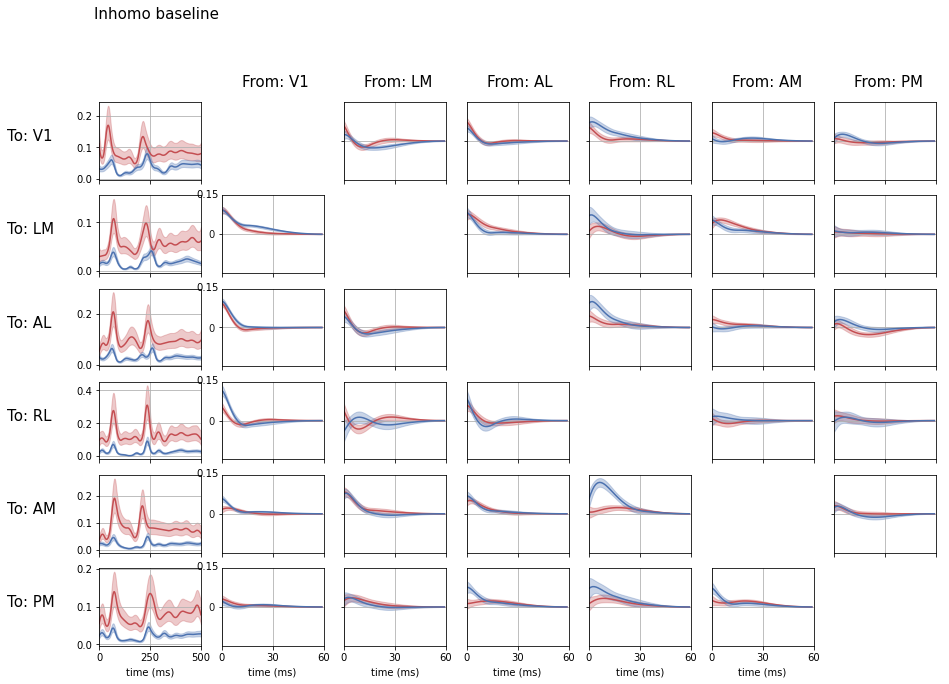

In [42]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=True, 
                              plot_self=False)

Text(0.5, 1.0, '$\\beta_{V1, m}$')

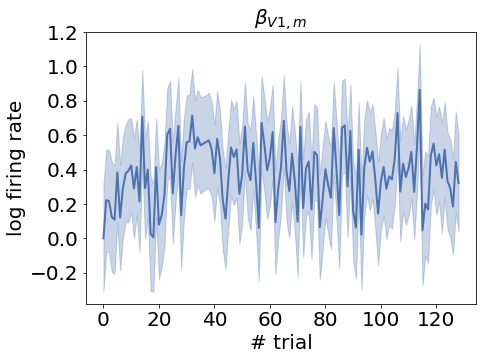

In [43]:
fontsize = 20
plt.subplots(figsize=(5*1.4,5))

utils.plot_ci(stationary_model_list[2].get_filter(ci=True)[8], center=True, linewidth=2)

plt.xlabel('# trial', fontsize=fontsize)
plt.ylabel('log firing rate', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title(r'$\beta_{V1, m}$', fontdict = {'fontsize' : 20})

# Two $\Lambda^{1.5}$ refractory in history effect with different time constant

In [44]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau1 = 5
tau2 = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau1, order=1.5, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau2, order=1.5, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau1, order=1.5, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau2, order=1.5, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")


6it [03:32, 35.42s/it]

AIC improvement of the model is: 30612.01263209409
BIC improvement of the model is: 25519.171038400964


5, 10: 29761.856376257725
5, 15: 29904.443967052386
5, 20: 29775.91234809812
5, 30: 29102.76408251538
10, 15:29743.358087155735
10, 20:29725.637462022016
10, 30:29640.518552740687
15, 20:29708.212010859977
15, 30:29812.91767771705
20, 30: 29579.453214338864
20, 40: 29472.82469279389

/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

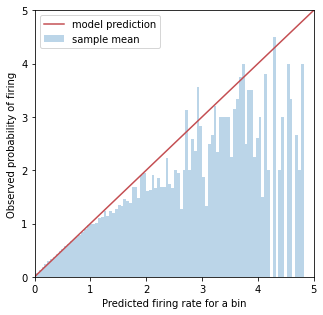

In [45]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

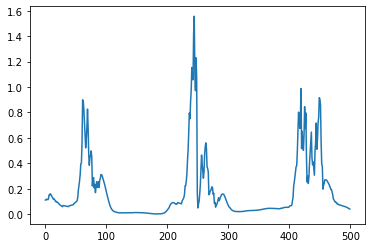

In [46]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

Text(0, 0.5, '$f_{refractory}(\\Lambda)$')

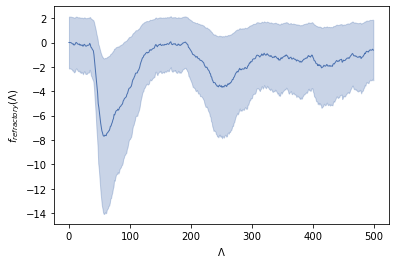

In [47]:
model = model_list[8]
utils.plot_ci(model.get_filter(ci=True)[8])
plt.xlabel('$\Lambda$')
plt.ylabel('$f_{refractory}(\Lambda)$')
# plt.ylim([-5, 0])

# Two refractory nonparametric in history effect with different time constant

In [48]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau1 = 15
tau2 = 5
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau1, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau2, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau1, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau2, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")


6it [03:26, 34.44s/it]

AIC improvement of the model is: 30146.754046770162
BIC improvement of the model is: 27388.131516853115


5, 10: 31369.47136813379
5, 15: 31557.04510426859
5, 20: 31331.06075825251
5, 30: 30866.218312508077
10, 15:31681.984163368703
10, 20:31470.324476118898
10, 30:31659.496173615567
15, 20:31699.159583152854
15, 30:31822.88428914058
20, 30:32286.324753385736

/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

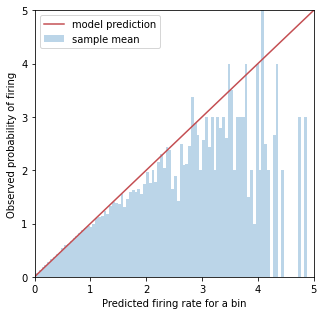

In [49]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

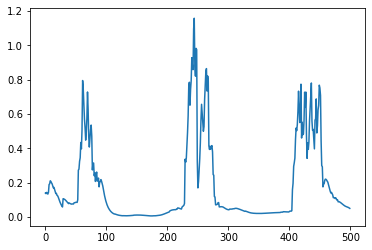

In [50]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

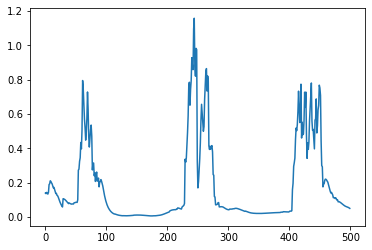

In [51]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

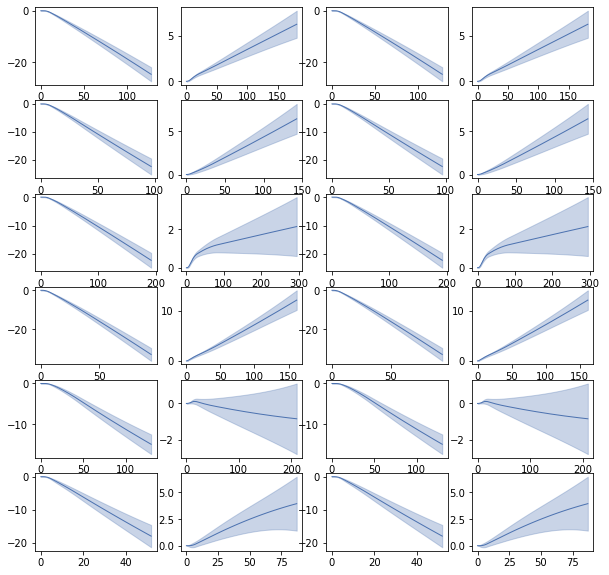

In [52]:
plt.subplots(figsize=(10,10))
for i in range(6):
    for j in range(7,9):
        plt.subplot(6,4, 4*i+j-6)
        model = model_list[i]
        utils.plot_ci(model.get_filter(ci=True)[j])
#         plt.xlabel('$\Lambda$')
#         plt.ylabel('$f_{refractory}(\Lambda)$')
    for j in range(7,9):
        plt.subplot(6,4, 4*i+j-4)
        model = model_list[i]
        utils.plot_ci(model.get_filter(ci=True)[j])
#         plt.xlabel('$\Lambda$')
#         plt.ylabel('$f_{refractory}(\Lambda)$')
# plt.ylim([-5, 0])

# Interaction in all coupling effects

Not so good

In [53]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_stationary.add_effect('interaction', probe_list[j], tau=tau, **coupling_filter_params, apply_no_penalty=True)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_running.add_effect('interaction', probe_list[j], tau=tau, **coupling_filter_params, apply_no_penalty=True)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")


6it [03:40, 36.79s/it]

AIC improvement of the model is: 30262.705700765713
BIC improvement of the model is: 22623.44331022608


/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

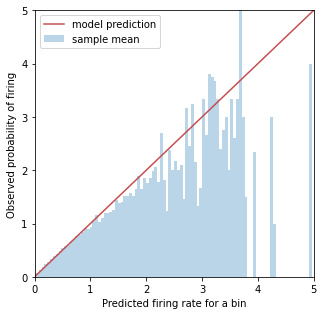

In [54]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

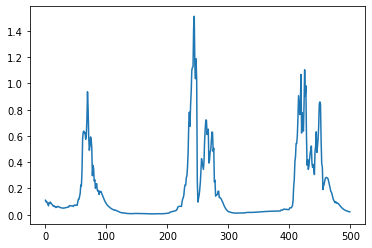

In [55]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# $\Lambda^{1.5}$ in all coupling effects

bad

In [56]:
# The following hyperparameters turned out to be the best

max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_stationary.add_effect('refractory', probe_list[j], tau=tau, order=1.5, **coupling_filter_params, 
                                    apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_running.add_effect('refractory', probe_list[j], tau=tau, order=1.5, **coupling_filter_params, 
                                    apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")


6it [03:24, 34.12s/it]

AIC improvement of the model is: 29721.803034686716
BIC improvement of the model is: 27175.382237840327


/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

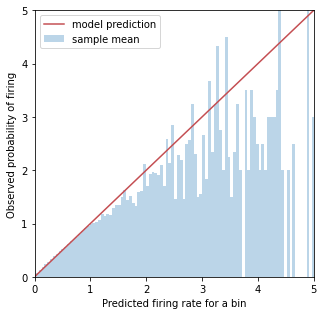

In [57]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

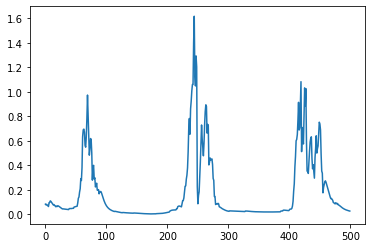

In [58]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# refractory nonparametric in all coupling effects

In [59]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_stationary.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_running.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")


6it [03:39, 36.54s/it]

AIC improvement of the model is: 29017.6771767179
BIC improvement of the model is: 24561.4407822364


/tmp/ipykernel_129107/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

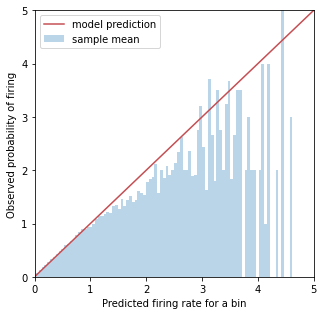

In [60]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

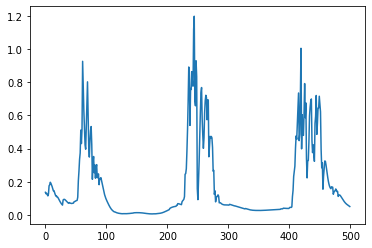

In [61]:
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]))

# Logistic model with $\Lambda^{1.5}$ refractory in history effect

In [62]:
# The following hyperparameters turned out to be the best

num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, method='logit',verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, method='logit',verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")


0it [00:01, ?it/s]


AssertionError: logit regression must use 0 penalty

In [ ]:
model_list = stationary_model_list + running_model_list
logit = lambda xb: 1/(1+np.exp(-xb))

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(model.max_spike*logit(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.title('Logistic model')

In [ ]:
model = stationary_model_list[3]
plt.plot(model.max_spike*logit(model.log_lmbd[:, 85]))

# Logistic model with refractory nonparametric in history effect

In [ ]:
# The following hyperparameters turned out to be the best

num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, method='logit',verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, method='logit',verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")


In [ ]:
sns.set_theme(style="white")
model_list = stationary_model_list + running_model_list
logit = lambda xb: 1/(1+np.exp(-xb))

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(model.max_spike*logit(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)

plt.xlim([0, 5])
plt.ylim([0, 5])

plt.legend(prop={'size': fontsize})
plt.xlabel('Predicted firing rate for a bin', fontsize=fontsize)
plt.ylabel('Observed probability of firing', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title('Binomial model', fontdict = {'fontsize' : 20})

In [ ]:
model = stationary_model_list[3]
plt.plot(model.max_spike*logit(model.log_lmbd[:, 85]))

In [ ]:
model = stationary_model_list[3]
plt.plot((model.log_lmbd[:, 85]))

In [ ]:
plt.subplots(figsize=(10,15))
for i in range(6):
    for j in range(7,8):
        plt.subplot(6,2, 2*i+j-6)
        model = model_list[i]
        plt.plot(model.get_filter(ci=False)[j])
#         plt.xlabel('$\Lambda$')
#         plt.ylabel('$f_{refractory}(\Lambda)$')
    for j in range(7,8):
        plt.subplot(6,2, 2*i+j-5)
        model = model_list[i]
        plt.plot(model.get_filter(ci=False)[j])
#         plt.xlabel('$\Lambda$')
#         plt.ylabel('$f_{refractory}(\Lambda)$')
# plt.ylim([-5, 0])

# Smaller time bin to avoid spike count >2, the under fit cases, but turned out to be the same

In [743]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=2000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [744]:
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':2*50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
#     model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    running_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_output[i,j] = filter_list[k]
        k += 1
    
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
#     model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    stationary_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_output[i,j] = filter_list[k]
        k += 1
    
    # for effect filter
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)

    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)
    
    # for effect output
    filter_index = i,-1
    function1 = np.exp( running_output[filter_index][0] )
    function2 = np.exp( stationary_output[filter_index][0] )
    ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)

    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_output[filter_index][0]
        function2 = stationary_output[filter_index][0]
        ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)


6it [05:32, 55.34s/it]


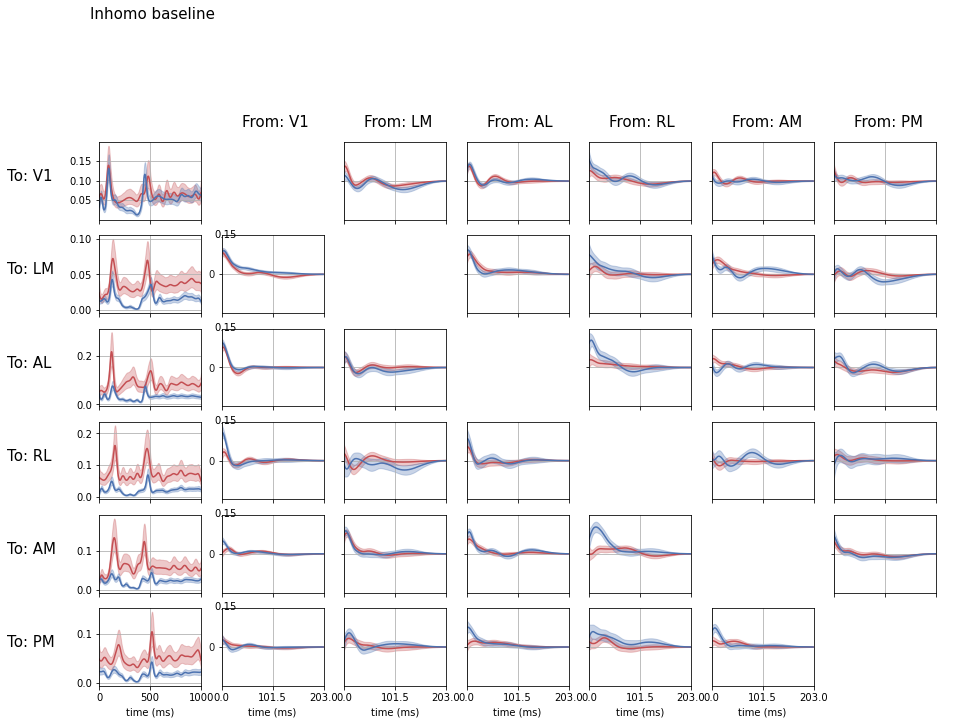

In [745]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=True, 
                              plot_self=False)

/tmp/ipykernel_23266/2549144781.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


Text(0.5, 1.0, 'model with 0.5ms time bin')

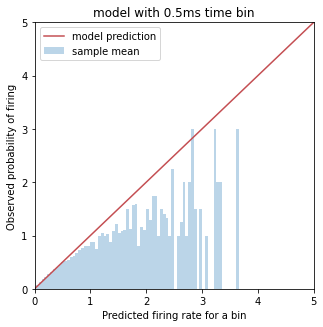

In [746]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.title('model with 0.5ms time bin')

# Individual neuron history

In [700]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=500,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [704]:
# The following hyperparameters turned out to be the best
max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50/2, 'num':6, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.stationary_trial_index
    # for neuron in neuron_list
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    model_stationary = GLM.fit_individual(model_stationary, target_probe, coupling_filter_params, verbose=False)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    model_running = GLM.fit_individual(model_running, target_probe, coupling_filter_params, verbose=False)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

# print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [02:52, 28.68s/it]


306750it [00:30, 9934.11it/s]
281000it [00:26, 10515.23it/s]
276750it [00:25, 10688.72it/s]
185250it [00:11, 15504.67it/s]
106250it [00:04, 25569.61it/s]
113000it [00:04, 24227.26it/s]
195750it [00:13, 14758.53it/s]
281000it [00:26, 10514.25it/s]
276750it [00:25, 10687.59it/s]
185250it [00:11, 15538.36it/s]
106250it [00:04, 25628.93it/s]
113000it [00:04, 24194.41it/s]


Text(0.5, 1.0, 'Single neuron level model')

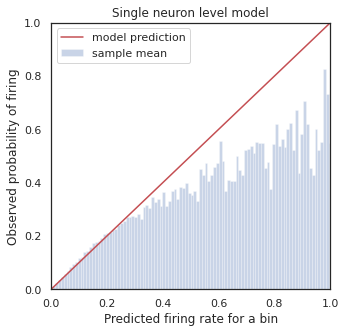

In [710]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.01
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in tqdm(enumerate(np.exp(model.log_lmbd).flatten('F'))):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.response_vec.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title('Single neuron level model')

# Final chosen model

See "Inference and simulation on the final model f_rf"